# Spark ile Makine Öğrenmesi

Bu çalışmamızda da PySpark kullanarak baştan sona tüm konuştuğumuz kavramları barındıran bir makine öğrenmesi modeli oluşturacağız. Hazırsanız başlayalım :)

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pyspark

Çalışmalarımıza başlamadan önce SparkSession oluşturalım.

In [0]:
spark = pyspark.sql.SparkSession.builder.getOrCreate()

In [0]:
# Veri setimizi okutalım
data = spark.read.csv('dbfs:/FileStore/tables/churn.txt',
                     inferSchema=True,
                     header=True)

data.printSchema()

root
 |-- State: string (nullable = true)
 |-- Account Length: integer (nullable = true)
 |-- Area Code: integer (nullable = true)
 |-- Phone: string (nullable = true)
 |-- Int'l Plan: string (nullable = true)
 |-- VMail Plan: string (nullable = true)
 |-- VMail Message: integer (nullable = true)
 |-- Day Mins: double (nullable = true)
 |-- Day Calls: integer (nullable = true)
 |-- Day Charge: double (nullable = true)
 |-- Eve Mins: double (nullable = true)
 |-- Eve Calls: integer (nullable = true)
 |-- Eve Charge: double (nullable = true)
 |-- Night Mins: double (nullable = true)
 |-- Night Calls: integer (nullable = true)
 |-- Night Charge: double (nullable = true)
 |-- Intl Mins: double (nullable = true)
 |-- Intl Calls: integer (nullable = true)
 |-- Intl Charge: double (nullable = true)
 |-- CustServ Calls: integer (nullable = true)
 |-- Churn?: string (nullable = true)



Eğer sütun isimlerimizde herhangi bir değişiklik yapmak istersek, bunu yapmak da oldukça basit :)

In [0]:
columns = ["state", "account_length", "area_code", "phone_number", "intl_plan", 
           "voice_mail_plan", "number_vmail_messages", 
           "total_day_minutes", "total_day_calls", "total_day_charge", 
           "total_eve_minutes", "total_eve_calls", "total_eve_charge", 
           "total_night_minutes", "total_night_calls", "total_night_charge", 
           "total_intl_minutes", "total_intl_calls", "total_intl_charge", 
           "number_customer_service_calls", "churned"]

old_columns = data.schema.names

# Değişikliği uygulayalım
for old,new in zip(old_columns,columns):
    data = data.withColumnRenamed(old, new)

data.printSchema()

root
 |-- state: string (nullable = true)
 |-- account_length: integer (nullable = true)
 |-- area_code: integer (nullable = true)
 |-- phone_number: string (nullable = true)
 |-- intl_plan: string (nullable = true)
 |-- voice_mail_plan: string (nullable = true)
 |-- number_vmail_messages: integer (nullable = true)
 |-- total_day_minutes: double (nullable = true)
 |-- total_day_calls: integer (nullable = true)
 |-- total_day_charge: double (nullable = true)
 |-- total_eve_minutes: double (nullable = true)
 |-- total_eve_calls: integer (nullable = true)
 |-- total_eve_charge: double (nullable = true)
 |-- total_night_minutes: double (nullable = true)
 |-- total_night_calls: integer (nullable = true)
 |-- total_night_charge: double (nullable = true)
 |-- total_intl_minutes: double (nullable = true)
 |-- total_intl_calls: integer (nullable = true)
 |-- total_intl_charge: double (nullable = true)
 |-- number_customer_service_calls: integer (nullable = true)
 |-- churned: string (nullable =

Önceki işlediğimiz notebookdan hatırlarsanız, bu değişikliği yapmanın farklı yolları da vardı.

```python
from pyspark.sql.types import StringType, DoubleType, StructType, StructField

schema = StructType([
    StructField("state", StringType(), True), 
    StructField("account_length", DoubleType(), True), 
    StructField("area_code", StringType(), True), 
    ...
    ...
    StructField("churned", StringType(), True)])
```

Şimdi de oluşturduğumuz PySpark DataFrame'i inceleyelim.

In [0]:
data.show()

+-----+--------------+---------+------------+---------+---------------+---------------------+-----------------+---------------+----------------+-----------------+---------------+----------------+-------------------+-----------------+------------------+------------------+----------------+-----------------+-----------------------------+-------+
|state|account_length|area_code|phone_number|intl_plan|voice_mail_plan|number_vmail_messages|total_day_minutes|total_day_calls|total_day_charge|total_eve_minutes|total_eve_calls|total_eve_charge|total_night_minutes|total_night_calls|total_night_charge|total_intl_minutes|total_intl_calls|total_intl_charge|number_customer_service_calls|churned|
+-----+--------------+---------+------------+---------+---------------+---------------------+-----------------+---------------+----------------+-----------------+---------------+----------------+-------------------+-----------------+------------------+------------------+----------------+-----------------+----

In [0]:
# Veri setinin anlaşılırlığını kolaylaştırması için Pandas DataFrame'e dönüştürelim
df = data.toPandas()
df

,state,account_length,area_code,phone_number,intl_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churned
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,414-4276,no,yes,36,156.2,77,26.55,...,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False.
3329,WV,68,415,370-3271,no,no,0,231.1,57,39.29,...,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False.
3330,RI,28,510,328-8230,no,no,0,180.8,109,30.74,...,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False.
3331,CT,184,510,364-6381,yes,no,0,213.8,105,36.35,...,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False.


In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   state                          3333 non-null   object 
 1   account_length                 3333 non-null   int32  
 2   area_code                      3333 non-null   int32  
 3   phone_number                   3333 non-null   object 
 4   intl_plan                      3333 non-null   object 
 5   voice_mail_plan                3333 non-null   object 
 6   number_vmail_messages          3333 non-null   int32  
 7   total_day_minutes              3333 non-null   float64
 8   total_day_calls                3333 non-null   int32  
 9   total_day_charge               3333 non-null   float64
 10  total_eve_minutes              3333 non-null   float64
 11  total_eve_calls                3333 non-null   int32  
 12  total_eve_charge               3333 non-null   f

## Veriyi Keşfetme

Spark'ın en önemli özelliklerinden biri de üzerinde **SQL** sorgularının yazılabilmesiydi. Hadi bu özelliğini veriyi keşfederken kullanalım.

In [0]:
data.registerTempTable('data') # Geçici tablo oluşturalım

# Artık bundan sonrası SQL :)
churn_counts = spark.sql("""SELECT churned, COUNT(churned) AS total
                            FROM data
                            GROUP BY churned""")

churn_counts.show()

/databricks/spark/python/pyspark/sql/dataframe.py:234: FutureWarning: Deprecated in 2.0, use createOrReplaceTempView instead.
  warnings.warn("Deprecated in 2.0, use createOrReplaceTempView instead.", FutureWarning)
+-------+-----+
|churned|total|
+-------+-----+
|  True.|  483|
| False.| 2850|
+-------+-----+



Yukarıdaki tablomuzda müşterilerin churning dağılımını görüyoruz. Beklendiği gibi churn eden müşterilerin sayısı, etmeyenlerle kıyaslandığında oldukça az. 

O zaman analizlerimize devam edelim.

In [0]:
state_customer_counts = spark.sql("""SELECT state, COUNT(state) AS total 
                                     FROM data 
                                     GROUP BY state 
                                     ORDER BY total DESC 
                                     LIMIT 10""")
state_customer_counts.show()

+-----+-----+
|state|total|
+-----+-----+
|   WV|  106|
|   MN|   84|
|   NY|   83|
|   AL|   80|
|   WI|   78|
|   OR|   78|
|   OH|   78|
|   VA|   77|
|   WY|   77|
|   CT|   74|
+-----+-----+



In [0]:
state_churn_counts = spark.sql("""SELECT state, COUNT(churned) as churned
                                  FROM data
                                  WHERE churned = 'True'
                                  GROUP BY state""")

state_churn_counts.show(10)

+-----+-------+
|state|churned|
+-----+-------+
+-----+-------+



> **SORU:** Hmm. Herhangi bir sonuç dönmedi. Neden olabilir?

In [0]:
state_churn_counts = spark.sql("""SELECT state, COUNT(churned) as churned
                                  FROM data
                                  WHERE churned LIKE '%True%'
                                  GROUP BY state""")

state_churn_counts.show(10)

+-----+-------+
|state|churned|
+-----+-------+
|   AZ|      4|
|   SC|     14|
|   LA|      4|
|   MN|     15|
|   NJ|     18|
|   DC|      5|
|   OR|     11|
|   VA|      5|
|   RI|      6|
|   WY|      9|
+-----+-------+
only showing top 10 rows



Şimdi de yukarıda oluşturduğumuz 2 tabloyu birleştirelim. Bunu PySpark DataFramelerini veya SQL bilgimizi kullanarak yapabiliriz. İlk olarak SQL...

In [0]:
state_customer_counts.registerTempTable('state_customer_counts')
state_churn_counts.registerTempTable('state_churn_counts')

# SQL Join
combined_state_data = spark.sql("""SELECT cust_cts.state, churned, total
                                   FROM state_customer_counts AS cust_cts
                                   INNER JOIN state_churn_counts AS churn_cts
                                   ON cust_cts.state = churn_cts.state""")
combined_state_data.show()

+-----+-------+-----+
|state|churned|total|
+-----+-------+-----+
|   MN|     15|   84|
|   OR|     11|   78|
|   VA|      5|   77|
|   WY|      9|   77|
|   WI|      7|   78|
|   CT|     12|   74|
|   AL|      8|   80|
|   OH|     10|   78|
|   NY|     15|   83|
|   WV|     10|  106|
+-----+-------+-----+



Şimdi de PySpark DataFrame...

In [0]:
# PySpark Join
combined_state_data2 = state_churn_counts.join(state_customer_counts, 
                                               on='state', 
                                               how='inner')

combined_state_data2 = combined_state_data2.sort('total', ascending=False)

combined_state_data2.show()

+-----+-------+-----+
|state|churned|total|
+-----+-------+-----+
|   WV|     10|  106|
|   MN|     15|   84|
|   NY|     15|   83|
|   AL|      8|   80|
|   WI|      7|   78|
|   OR|     11|   78|
|   OH|     10|   78|
|   VA|      5|   77|
|   WY|      9|   77|
|   CT|     12|   74|
+-----+-------+-----+



## Veri Ön İşleme

`intl_plan`, `voice_mail_plan` ve `churned` gibi veri tipini `boolean` olarak düzeltmemiz gereken sütunlarımız var. Biraz da ön işleme işlemleri yapalım.

In [0]:
from pyspark.sql.functions import udf

# Analizde kullanmayacağımız sütunlar
for field in ['state', 'area_code', 'phone_number']:
    data = data.drop(field)

def trim(string):
    return (string
            .strip()
            .replace('.','')
            .replace('yes','True')
            .replace('no','False'))

# Aynı Pandasta kullandığımız apply/map fonksiyonlar gibi trim fonksiyonumuzu da UDF olarak tanımlayalım
trim = udf(trim)

for dtype in data.dtypes:
    column = dtype[0] # Sütun ismi
    if dtype[1] == 'string': # Sütun veri tipi
        data = data.withColumn(column, trim(data[column]))

# Dönüşümleri gerçekleştirelim
for column in ['intl_plan', 'voice_mail_plan']:
    data = data.withColumn(column, data[column].cast('boolean').cast('int'))
    
data = data.withColumn('churned', data['churned'].cast('boolean').cast('double'))

Şimdi de değişkenlerimiz arasındaki ilişkileri gözlemleyelim.

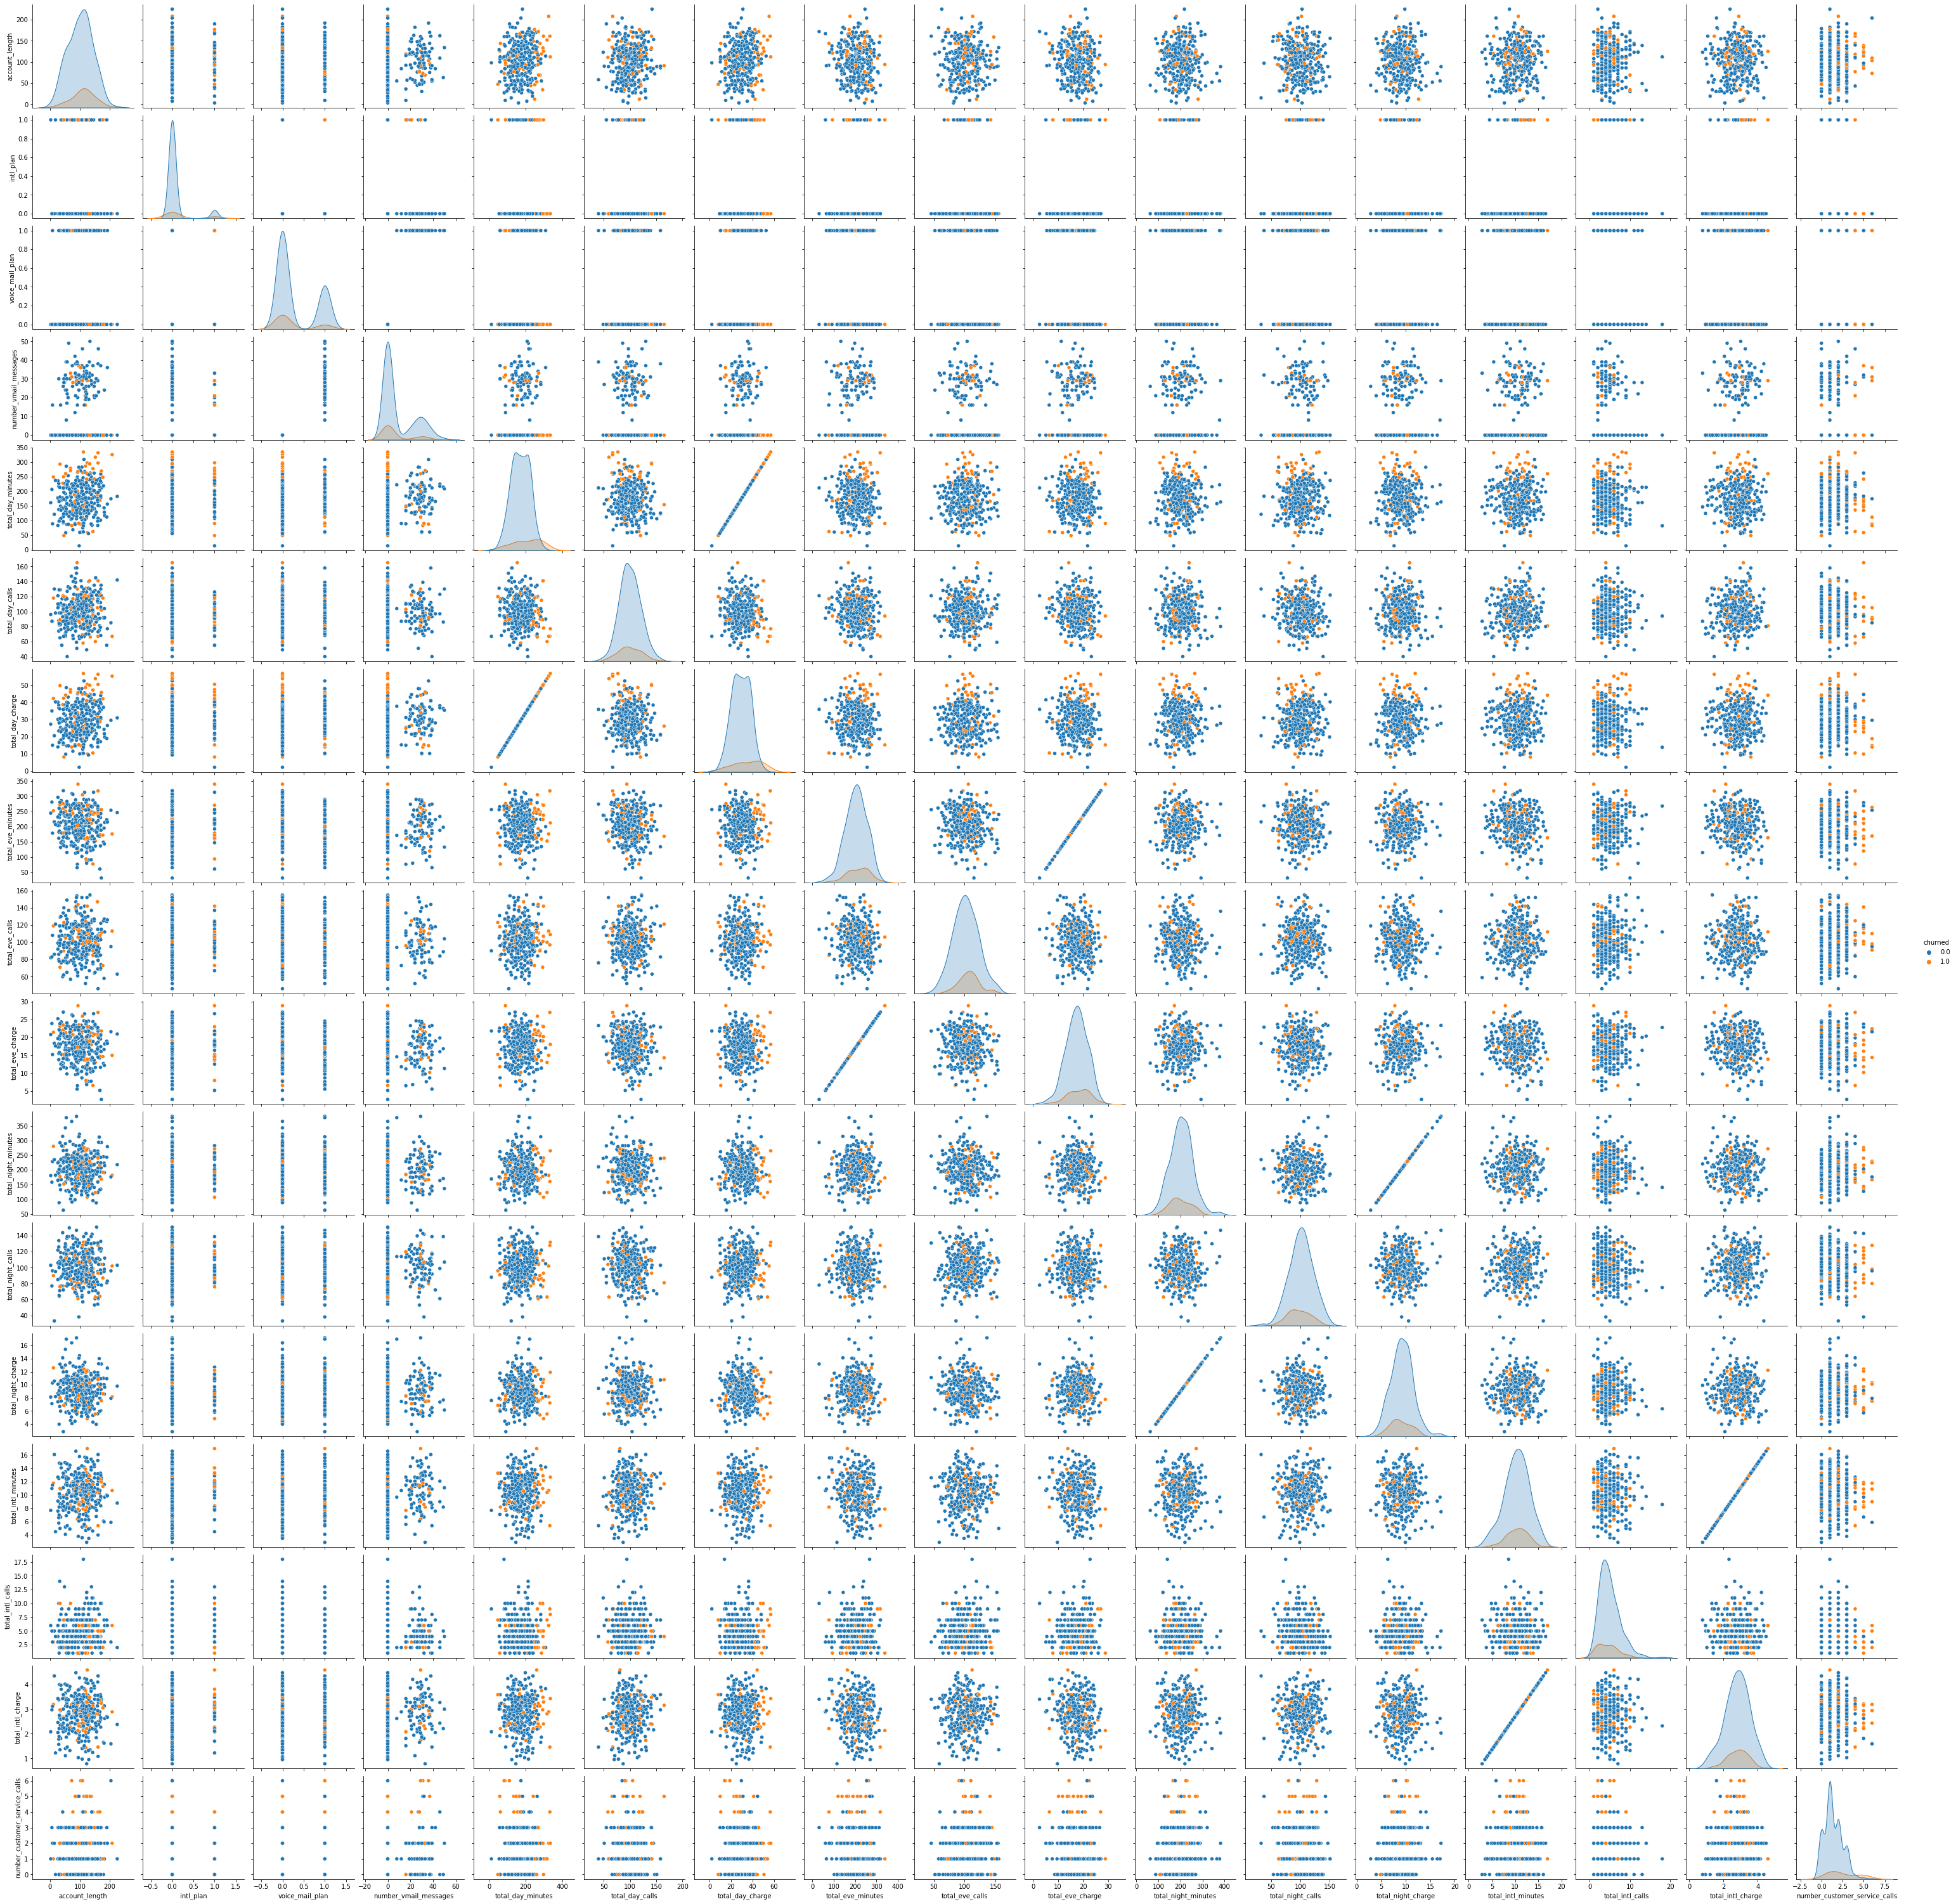

In [0]:
# %10'luk örneklem üzerinden incelemeyi yapalım
sampled_data = data.sample(False, 0.1).toPandas()

sns.pairplot(sampled_data, hue='churned');

Yukarıdaki grafiğe baktığımızda dikkatimizi çeken ilk durumlardan biri **bazı featurelar arasında çok yüksek derecede ilişkiler** görülmesi (bknz. `total_intl_charge`/ `total_intl_minutes`). O zaman bu featurelardan kurtalım.

## Makine Öğrenmesine Hazırlık

Modellerimizi oluşturmaya başlamadan önce yapmamız gereken ilk adım veri setimizi bölümlemekti. Bakalım PySpark'da bu işlemi nasıl yapabiliyoruz.

```python
train, valid, test = data.randomSplit([0.6, 0.2, 0.2], seed=42) # %60 Train, %20 Validation, %20 Test
```

In [0]:
data = data.drop('total_day_charge', 'total_night_charge', 'total_eve_charge', 'total_intl_charge')
    
data.printSchema()

root
 |-- account_length: integer (nullable = true)
 |-- intl_plan: integer (nullable = true)
 |-- voice_mail_plan: integer (nullable = true)
 |-- number_vmail_messages: integer (nullable = true)
 |-- total_day_minutes: double (nullable = true)
 |-- total_day_calls: integer (nullable = true)
 |-- total_eve_minutes: double (nullable = true)
 |-- total_eve_calls: integer (nullable = true)
 |-- total_night_minutes: double (nullable = true)
 |-- total_night_calls: integer (nullable = true)
 |-- total_intl_minutes: double (nullable = true)
 |-- total_intl_calls: integer (nullable = true)
 |-- number_customer_service_calls: integer (nullable = true)
 |-- churned: double (nullable = true)



In [0]:
data.toPandas()

,account_length,intl_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_eve_minutes,total_eve_calls,total_night_minutes,total_night_calls,total_intl_minutes,total_intl_calls,number_customer_service_calls,churned
0,128,0,1,25,265.1,110,197.4,99,244.7,91,10.0,3,1,0.0
1,107,0,1,26,161.6,123,195.5,103,254.4,103,13.7,3,1,0.0
2,137,0,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0.0
3,84,1,0,0,299.4,71,61.9,88,196.9,89,6.6,7,2,0.0
4,75,1,0,0,166.7,113,148.3,122,186.9,121,10.1,3,3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,192,0,1,36,156.2,77,215.5,126,279.1,83,9.9,6,2,0.0
3329,68,0,0,0,231.1,57,153.4,55,191.3,123,9.6,4,3,0.0
3330,28,0,0,0,180.8,109,288.8,58,191.9,91,14.1,6,2,0.0
3331,184,1,0,0,213.8,105,159.6,84,139.2,137,5.0,10,2,0.0


In [0]:
train, test = data.randomSplit([0.7, 0.3], seed=42)

Sklearn kullanarak modellerimizi oluştururken `train_test_split` işlemine tabi tutmadan **Feature(X)** ve **Target(Y)** ayrımımızı gerçekleştiriyorduk. Ancak PySpark'da işlem adımları biraz daha farklı, burada **feature olarak kullanacağımız sütunların tamamını tek bir sütunda** toplamamız gerekiyor. Bu işlemi gerçekleştirmek için ise `VectorAssembler` kullanıyoruz.

In [0]:
train.toPandas()

,account_length,intl_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_eve_minutes,total_eve_calls,total_night_minutes,total_night_calls,total_intl_minutes,total_intl_calls,number_customer_service_calls,churned
0,1,0,0,0,123.8,113,236.2,77,73.2,81,3.7,2,0,0.0
1,1,0,0,0,144.8,107,112.5,66,218.7,79,13.8,3,1,0.0
2,1,0,0,0,182.1,106,134.9,106,152.3,75,10.0,3,5,1.0
3,1,0,0,0,196.1,107,296.5,82,211.5,91,7.0,2,1,0.0
4,1,0,1,26,146.6,68,172.8,67,173.8,113,10.0,2,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2383,217,0,0,0,123.7,138,248.5,105,269.6,78,13.3,4,0,0.0
2384,217,0,0,0,176.4,115,158.8,128,306.6,107,9.3,3,4,0.0
2385,221,0,1,24,180.5,85,224.1,92,205.7,103,2.4,3,0,0.0
2386,225,0,0,0,165.4,106,273.7,109,210.0,93,8.7,3,0,1.0


In [0]:
from pyspark.ml.feature import VectorAssembler

features = data.schema.names[:-1]

assembler = VectorAssembler(inputCols=features, outputCol='features')

# Dönüştürme İşlemi
train_pack = assembler.transform(train)
test_pack = assembler.transform(test)

# Orjinal sütunları artık kullanmayacaksak kaldırabiliriz
for field in features:
    train_pack = train_pack.drop(field)
    test_pack  = test_pack.drop(field)

In [0]:
train_pack.show()

+-------+--------------------+
|churned|            features|
+-------+--------------------+
|    0.0|[1.0,0.0,0.0,0.0,...|
|    0.0|[1.0,0.0,0.0,0.0,...|
|    1.0|[1.0,0.0,0.0,0.0,...|
|    0.0|[1.0,0.0,0.0,0.0,...|
|    0.0|[1.0,0.0,1.0,26.0...|
|    0.0|[1.0,0.0,1.0,30.0...|
|    0.0|[3.0,0.0,0.0,0.0,...|
|    0.0|[3.0,0.0,1.0,27.0...|
|    0.0|[3.0,0.0,1.0,36.0...|
|    0.0|[6.0,0.0,0.0,0.0,...|
|    0.0|[6.0,0.0,0.0,0.0,...|
|    0.0|[7.0,0.0,0.0,0.0,...|
|    0.0|[8.0,0.0,1.0,36.0...|
|    0.0|[9.0,0.0,1.0,31.0...|
|    0.0|[10.0,0.0,0.0,0.0...|
|    0.0|[10.0,0.0,0.0,0.0...|
|    0.0|[11.0,0.0,0.0,0.0...|
|    0.0|[12.0,0.0,0.0,0.0...|
|    0.0|[12.0,1.0,0.0,0.0...|
|    0.0|[13.0,0.0,0.0,0.0...|
+-------+--------------------+
only showing top 20 rows



In [0]:
test_pack.show()

+-------+--------------------+
|churned|            features|
+-------+--------------------+
|    0.0|[1.0,0.0,0.0,0.0,...|
|    0.0|[1.0,0.0,1.0,26.0...|
|    1.0|[2.0,1.0,0.0,0.0,...|
|    0.0|[3.0,0.0,0.0,0.0,...|
|    0.0|[3.0,1.0,0.0,0.0,...|
|    0.0|[4.0,1.0,0.0,0.0,...|
|    0.0|[5.0,0.0,0.0,0.0,...|
|    0.0|[7.0,0.0,1.0,30.0...|
|    0.0|[9.0,0.0,1.0,16.0...|
|    0.0|[9.0,0.0,1.0,39.0...|
|    0.0|[10.0,0.0,0.0,0.0...|
|    0.0|[11.0,0.0,1.0,24....|
|    0.0|[11.0,0.0,1.0,28....|
|    0.0|[11.0,0.0,1.0,38....|
|    1.0|[12.0,0.0,0.0,0.0...|
|    0.0|[13.0,0.0,0.0,0.0...|
|    0.0|[13.0,0.0,0.0,0.0...|
|    1.0|[13.0,0.0,0.0,0.0...|
|    0.0|[13.0,0.0,1.0,31....|
|    0.0|[15.0,0.0,0.0,0.0...|
+-------+--------------------+
only showing top 20 rows



>**SORU:** Scaling konusunu hatırlıyor musunuz? Elimizdeki verilere ne zaman Scaling uyguluyorduk?

In [0]:
from pyspark.ml.feature import MinMaxScaler

minmaxscale = MinMaxScaler(inputCol='features', outputCol='features_scaled')

minmaxscale_train = minmaxscale.fit(train_pack)
minmaxscale_test = minmaxscale.fit(test_pack)

train_pack = minmaxscale_train.transform(train_pack)
test_pack  = minmaxscale_test.transform(test_pack)

## Model Oluşturma

PySpark'ın kullanılabilir 2 tane ML kütüphanesi vardır:

1. **MLLib:** Daha Eski, RDD'lere Dayalı, Daha Eksiksiz, Spark 2.0'dan itibaren güncelliği yitirdi
2. **ML:** Güncel Versiyon, DataFrame'lere Dayalı, MLLib'den daha az özelliği var ama hala geliştirilmelere devam ediyor

Biz ise data güncel olduğu için **çoğunlukla ML kütüphanesiyle** çalışmalarımıza devam edeceğiz.

>**NOT:** Spark hakkında konuşurken makine öğrenmesi kütüphanesi genellikle **MLLib** olarak tasvir edilir. Ama kullanılan bu kavram aslında ikisini de içerir :)

Şimdi 4 tane algoritmayı kullanarak modellerimizi oluşturmaya başlayalım.

In [0]:
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier, GBTClassifier, LogisticRegression

1. **Sklearn:** `.fit()`: Modeli Eğitme, `predict()`: Tahmin Etme
2. **PySpark ML:** `.fit()`: Modeli Eğitme, `transform()`: Tahmin Etme

In [0]:
# Logistic Regression
lr = LogisticRegression(labelCol='churned', 
                        featuresCol='features_scaled',
                        predictionCol='prediction')

lr_model = lr.fit(train_pack)
lr_pred = lr_model.transform(test_pack)

# Decision Tree
dt = DecisionTreeClassifier(labelCol='churned', 
                            featuresCol='features',
                            predictionCol='prediction')

dt_model = dt.fit(train_pack)
dt_pred = dt_model.transform(test_pack)

# Random Forest
rf = RandomForestClassifier(labelCol='churned',
                            featuresCol='features',
                            predictionCol='prediction')

rf_model = rf.fit(train_pack)
rf_pred = rf_model.transform(test_pack)

# Gradient Boosted Tree
gbt = GBTClassifier(labelCol='churned', 
                    featuresCol='features',
                    predictionCol='prediction')

gbt_model = gbt.fit(train_pack)
gbt_pred = gbt_model.transform(test_pack)

## Model Değerlendirme

In [0]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

accuracy = MulticlassClassificationEvaluator(labelCol='churned',
                                             predictionCol='prediction',
                                             metricName='accuracy')

precision = MulticlassClassificationEvaluator(labelCol='churned',
                                              predictionCol='prediction',
                                              metricName='weightedPrecision')

recall = MulticlassClassificationEvaluator(labelCol='churned',
                                           predictionCol='prediction',
                                           metricName='weightedRecall')

f1 = MulticlassClassificationEvaluator(labelCol='churned',
                                       predictionCol='prediction',
                                       metricName='f1')

areaROC = BinaryClassificationEvaluator(labelCol='churned',
                                        rawPredictionCol='prediction',
                                        metricName='areaUnderROC')

Bu sonuçları daha rahat karşılaştırmak için bir DataFrame oluşturalım.

In [0]:
metrics = [accuracy, precision, recall, f1, areaROC]
metric_labels = ['accuracy', 'precision', 'recall', 'f1', 'areaROC']

predictions = [lr_pred, dt_pred, rf_pred, gbt_pred]
predict_labels = ['LR', 'DT', 'RF', 'GBT']

eval_list = list()

# DataFrame Hazırlama
for pred in zip(predict_labels, predictions):
    name = pred[0]
    predict = pred[1]
    
    metric_vals = pd.Series(dict([(x[0], x[1].evaluate(predict)) for x in zip(metric_labels, metrics)]), name=name)
    eval_list.append(metric_vals)
    
# DataFrame Oluşturma
eval_df = pd.concat(eval_list, axis=1).T
eval_df = eval_df[metric_labels]
eval_df

,accuracy,precision,recall,f1,areaROC
LR,0.856085,0.836745,0.856085,0.842354,0.645144
DT,0.934392,0.933935,0.934392,0.928729,0.803328
RF,0.903704,0.898428,0.903704,0.891418,0.719168
GBT,0.953439,0.952486,0.953439,0.951482,0.872011


**Confusion Matrix** gibi hata metrikleri henüz **ML kütüphanesinde yok**. O yüzden **MLLib'e başvurmamız gerekiyor**. Hatırlarsanız MLLib kütüphanesini için PySpark DataFrame'ini doğrudan kullanamıyorduk. Ama bu sorunu küçük bir dönüşümle kolaylıkla çözebiliriz.

In [0]:
from pyspark.mllib.evaluation import BinaryClassificationMetrics, MulticlassMetrics

def evaluate_model_predictions(prediction_list, prediction_labels):
    
    eval_list = list()

    for pred in zip(prediction_labels, prediction_list):
        name = pred[0]
        predict = pred[1]

        # PySpark DataFrame'den RDD dönüşümü
        predict_rdd = predict[['prediction', 'churned']].rdd
        
        b_metrics = BinaryClassificationMetrics(predict_rdd)
        m_metrics = MulticlassMetrics(predict_rdd)

        metric_vals = pd.Series({'accuracy'        : m_metrics.accuracy,
                                 'precision'       : m_metrics.precision(0),
                                 'recall'          : m_metrics.recall(0),
                                 'areaROC'         : b_metrics.areaUnderROC,
                                 'confusion matrix': m_metrics.confusionMatrix().toArray().astype('int')},
                                name=name)
        eval_list.append(metric_vals)

    # DataFrame Hazırlama
    eval_df = pd.concat(eval_list, axis=1).T
    
    metric_labels = ['accuracy', 'precision', 'recall', 'areaROC', 'confusion matrix']
    eval_df = eval_df[metric_labels]
    
    return eval_df

predictions = [lr_pred, dt_pred, rf_pred, gbt_pred]
predict_labels = ['LR', 'DT', 'RF', 'GBT']

eval_df2 = evaluate_model_predictions(predictions, predict_labels)
eval_df2

/databricks/spark/python/pyspark/sql/context.py:165: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


,accuracy,precision,recall,areaROC,confusion matrix
LR,0.856085,0.88993,0.947631,0.645144,"[[760, 42], [94, 49]]"
DT,0.934392,0.935294,0.991272,0.803328,"[[795, 7], [55, 88]]"
RF,0.903704,0.910035,0.983791,0.719168,"[[789, 13], [78, 65]]"
GBT,0.953439,0.957729,0.988778,0.872011,"[[793, 9], [35, 108]]"


## ParamGridBuilder & Cross-Validation

In [0]:
# Çalışması biraz zaman alabilir
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml import Pipeline

# Gradient Boosted Tree
gbt2 = GBTClassifier(featuresCol='features',
                     labelCol='churned', 
                     predictionCol='prediction')
 
# Pipeline
pipeline = Pipeline(stages=[assembler, gbt2]) 

# Optimize etmek istediğimiz parametreler
paramgrid = (ParamGridBuilder().addGrid(gbt2.maxDepth, [4,6])
                               .addGrid(gbt2.stepSize, [0.001, 0.01, 0.1, 1.0]).build())

# F1 Score'a göre en iyi modeli bul 
evaluator = MulticlassClassificationEvaluator(labelCol='churned', 
                                              predictionCol='prediction', 
                                              metricName='f1') 

# 3 parçalı Cross-Validation 
crossval = CrossValidator(estimator=pipeline, 
                          estimatorParamMaps=paramgrid, 
                          evaluator=evaluator, 
                          numFolds=3) 

gbt2_model = crossval.fit(train) 

Bakalım en iyi modelimiz nasılmış?

In [0]:
# En iyi model
best_pipeline = gbt2_model.bestModel

# En iyi modelin parametreleri
best_gbt_model = best_pipeline.stages[1]
best_gbt_model

Out[30]: GBTClassificationModel: uid = GBTClassifier_25a95ba9dd2b, numTrees=20, numClasses=2, numFeatures=13

Maalesef, PySpark'taki `ParamGridBuilder()` kullanılarak algoritmaların tüm parametreleri optimize edilemiyor. Böyle bir ihtiyacımız olduğunda önceden öğrendiğimiz `GridSearchCV` veya `RandomizedSearchCV()` gibi araçlara başvurmamız gerekiyor.

Şimdi de en iyi olarak seçtiğimiz modelin feature importance değerlerine bakalım.

In [0]:
# Feature importance
feature_importances = best_gbt_model.featureImportances.toArray()

# Kullandığımız featurelar
feature_names = train.columns[:-1]

feature_series = (pd.Series(dict(zip(feature_names, feature_importances)))
                  .sort_values(ascending=False))

feature_series

Out[31]: total_eve_minutes                0.222726
total_day_minutes                0.214904
intl_plan                        0.203409
number_customer_service_calls    0.077956
number_vmail_messages            0.070047
total_intl_minutes               0.060517
total_intl_calls                 0.055898
total_night_minutes              0.049109
voice_mail_plan                  0.023848
total_night_calls                0.010964
total_day_calls                  0.006677
total_eve_calls                  0.002671
account_length                   0.001274
dtype: float64

Daha kolay bir karşılaştırma için elde ettiğimiz sonuçlara hemen bir görsele dökelim.

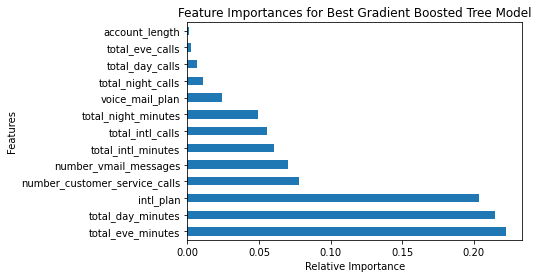

In [0]:
ax = feature_series.plot(kind='barh')
_ = ax.set(xlabel='Relative Importance', 
           ylabel='Features', 
           title='Feature Importances for Best Gradient Boosted Tree Model')

fig = plt.gcf()

fig.savefig('feature_importances.png')

## Test Veri Setinde Değerlendirme

Son olarak tüm yaptığımız bu işlem sonucunda elde ettiğimiz hata metriklerimizi inceleyelim.

In [0]:
gbt_pred_test = best_pipeline.transform(test)

evaluate_model_predictions([gbt_pred_test], ['GBT_GridSearch'])

/databricks/spark/python/pyspark/sql/context.py:165: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


,accuracy,precision,recall,areaROC,confusion matrix
GBT_GridSearch,0.941799,0.939929,0.995012,0.819185,"[[798, 4], [51, 92]]"
